Dataset: Titanic - Machine Learning from Disaster

(https://www.kaggle.com/competitions/titanic/data)
<hr>
Menggunakan teknik supervised learning Naive Bayes (Categorical Naive Bayes)

Data Dictionary:
<br>survival = Status kelangsungan hidup | 0 = Tidak selamat, 1 = Selamat
<br>pclass = Kelas tiket | 1 = Kelas 1, 2 = Kelas 2, 3 = Kelas 3
<br>sex = Jenis kelamin
<br>age	= Usia (dalam tahun)
<br>sibsp = Jumlah saudara / pasangan di kapal
<br>parch = Jumlah orang tua / anak di kapal
<br>ticket = Nomor tiket
<br>fare = Tarif penumpang
<br>cabin =	Nomor kabin
<br>embarked = Pelabuhan keberangkatan | C = Cherbourg, Q = Queenstown, S = Southampton


In [2]:
# Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.naive_bayes import CategoricalNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv("train.csv")

df.head() # Tampilin 5 data teratas

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.describe() # Tampilin ringkasan dataset

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
df.info() # Tampilin informasi umum dataset

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [5]:
print("Cek missing value per fitur:")
print(df.isnull().sum()) # Cek missing value perfitur

Cek missing value per fitur:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [6]:
df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin']) # Buang fitur yang tidak relevan
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [7]:
df['Age'] = df['Age'].fillna(df['Age'].median()) # Isi missing value pada fitur age dengan nilai tengah
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0]) # Isi missing value pada fitur embarked dengan nilai yang sering muncul

# Mengubah data numerik menjadi kategori untuk menyesuaikan dengan karakteristik Categorical Naive Bayes yang bekerja lebih baik pada data diskrit(1)
def kategori_umur(age):
  if age <= 5:
    return 'Balita'
  elif age <= 12:
    return 'Anak-anak'
  elif age <= 19:
    return 'Remaja'
  elif age <= 50:
    return 'Dewasa'
  else:
    return 'Lansia'

# Membuat sebuah fitur baru berdasarkan perubahan dari data numerik menjadi kategori(1)
df['AgeCategory'] = df['Age'].apply(kategori_umur)

# (2)
def kategori_sibsp(sib):
  if sib == 0:
    return 'Sendiri'
  elif sib <= 2:
    return 'Keluarga kecil'
  else:
    return 'Keluarga besar'

df['SibSpCategory'] = df['SibSp'].apply(kategori_sibsp) # (2)

# (3)
def kategori_parch(par):
  if par == 0:
    return 'Sendiri'
  elif par <= 2:
    return 'Keluarga kecil'
  else:
    return 'Keluarga besar'

df['ParchCategory'] = df['Parch'].apply(kategori_parch) # (3)

# Membuat sebuah fitur baru berdasarkan perubahan dari data numerik menjadi kategori berdasarkan nilai tertentu
df['FareCategory'] = pd.cut(df['Fare'],
                    bins=[0, 10, 50, 100, 1000],
                    labels=['Murah', 'Sedang', 'Mahal', 'Sangat Mahal'])

df['FareCategory'] = df['Fare'].fillna(df['Fare'].mode()[0]) # (4)

df['FamilySize'] = df['SibSp'] + df['Parch'] + 1 # Membuat fitur baru FamilySize dengan menjumlahkan jumlah SibSp, Parch, dan diri sendiri
df['IsAlone'] = df['FamilySize'].apply(lambda x: 'Ya' if x == 1 else 'Tidak') # Membuat sebuah fitur baru IsAlone dengan melihat jumlah FamilySize
df['FarePerPerson'] = df['Fare'] / df['FamilySize'] # Membuat fitur FarePerPerson dengan membagi total harga tiket dengan jumlah anggota keluarga untuk mendapatkan estimasi biaya per orang

# (5)
def kategori_keluarga(size):
  if size == 1:
    return 'Sendiri'
  elif size <= 4:
    return 'Keluarga kecil'
  else:
    return 'Keluarga besar'

# (5)
df['CategoryFamilySize'] = df['FamilySize'].apply(kategori_keluarga)

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,AgeCategory,SibSpCategory,ParchCategory,FareCategory,FamilySize,IsAlone,FarePerPerson,CategoryFamilySize
0,0,3,male,22.0,1,0,7.2500,S,Dewasa,Keluarga kecil,Sendiri,7.2500,2,Tidak,3.62500,Keluarga kecil
1,1,1,female,38.0,1,0,71.2833,C,Dewasa,Keluarga kecil,Sendiri,71.2833,2,Tidak,35.64165,Keluarga kecil
2,1,3,female,26.0,0,0,7.9250,S,Dewasa,Sendiri,Sendiri,7.9250,1,Ya,7.92500,Sendiri
3,1,1,female,35.0,1,0,53.1000,S,Dewasa,Keluarga kecil,Sendiri,53.1000,2,Tidak,26.55000,Keluarga kecil
4,0,3,male,35.0,0,0,8.0500,S,Dewasa,Sendiri,Sendiri,8.0500,1,Ya,8.05000,Sendiri


In [8]:
print(df.isnull().sum())

Survived              0
Pclass                0
Sex                   0
Age                   0
SibSp                 0
Parch                 0
Fare                  0
Embarked              0
AgeCategory           0
SibSpCategory         0
ParchCategory         0
FareCategory          0
FamilySize            0
IsAlone               0
FarePerPerson         0
CategoryFamilySize    0
dtype: int64


Akurasi Categorical NB: 75.37%

-- Laporan klasifikasi categorical NB --
              precision    recall  f1-score   support

           0       0.77      0.83      0.80       157
           1       0.73      0.65      0.69       111

    accuracy                           0.75       268
   macro avg       0.75      0.74      0.74       268
weighted avg       0.75      0.75      0.75       268



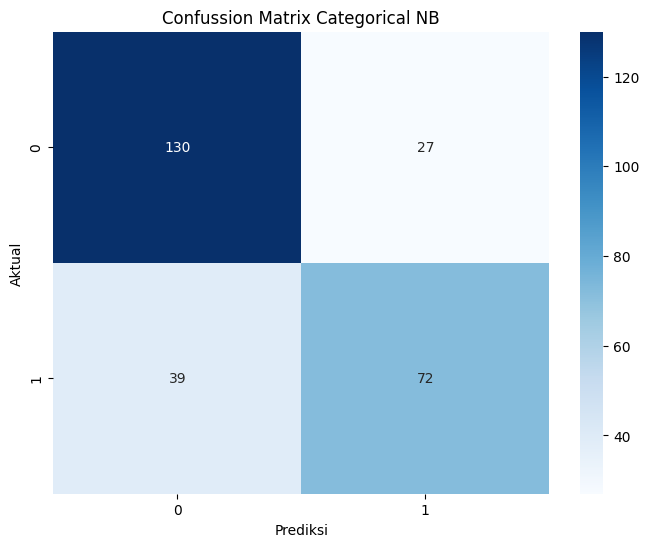

In [ ]:
# Memisahkan dataset menjadi fitur (X) dan target (y), di mana X berisi semua kolom kecuali Survived, dan y berisi kolom Survived
X = df.drop(columns=['Survived'])
y = df['Survived']

# Mengubah fitur kategorikal menjadi representasi numerik menggunakan OrdinalEncoder
encoder = OrdinalEncoder()
X = encoder.fit_transform(X)

# Membagi data training dan test, training = 80%, test = 20%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Melatih model Categorical NB menggunakan data latih (X_train dan y_train), kemudian digunakan untuk memprediksi data uji (X_test)
nb = CategoricalNB().fit(X_train, y_train)
y_pred = nb.predict(X_test)

# Menampilkan jumlah akurasi dan memuat laporan klasifikasi dari categorical NB
print(f"Akurasi Categorical NB: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\n-- Laporan klasifikasi categorical NB --")
print(classification_report(y_test, y_pred))

# Membuat confussion matrix untuk data latih dan data uji
cm = confusion_matrix(y_test, y_pred)

# Menampilkan plot untuk visualisasi
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
xticklabels=nb.classes_, yticklabels=nb.classes_)

plt.title("Confussion Matrix Categorical NB")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.show()
